#                   End-to-End Customer Churn Prediction ML Project.

# Situation
A company was losing customers every month, which was efecting it's revenue, The company wanted to understad why customes are leving our service and identify customers who are likly to churn.

# Task
My Task was to analyze the customer data, find the main resons behind the churn, and build a machine learning model to pretict customers who might leaving so the company could improve customer retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import warnings
from sklearn.exceptions import ConvergenceWarning 
from sklearn.exceptions import UndefinedMetricWarning

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC                         # Find best boundry 
from sklearn.ensemble import RandomForestClassifier # Mant trees vote together
from sklearn.neighbors import KNeighborsClassifier  # look at the nearest neighbors
from sklearn.linear_model import LogisticRegression # calculate probability then classify

from sklearn.naive_bayes import GaussianNB          # Choose the most probable class using Bayes' Theorem.

from sklearn.tree import DecisionTreeClassifier     # Ask questions one by one.
from xgboost import XGBClassifier                   # Each tree fixes previous mistakes.
from lightgbm import LGBMClassifier                 # Same as XGBoost, but faster and lighter.
from catboost import CatBoostClassifier             # Same as XGBoost, but automatically handles categorical data.


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
import pickle 

In [2]:
# Load Dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# See Statidtical summary of numeric columns
df.describe().round()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


In [6]:
# See number of unique rows of each columns
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
# see number of null values of each columns
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
print("Customer churn counts")
print(df['Churn'].value_counts())

Customer churn counts
Churn
No     5174
Yes    1869
Name: count, dtype: int64


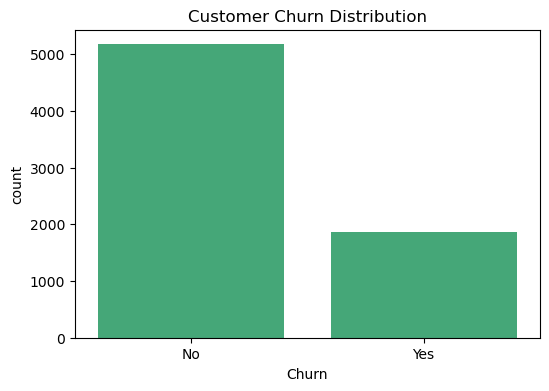

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, color='#35B779')
plt.title("Customer Churn Distribution")
plt.show()

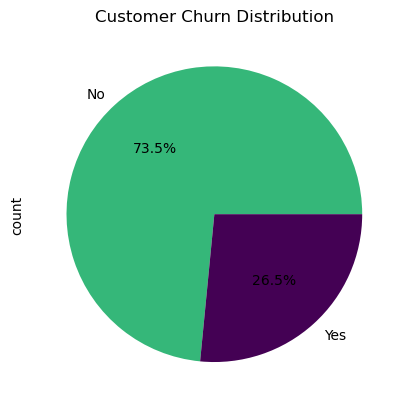

In [10]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#35B779', '#440154']
)

plt.title("Customer Churn Distribution")
plt.show()

### Observation:
Approximately 26.5% of customers churned, meaning they stopped using the company's telecom services. Around 73.5% of customers remained with the company.

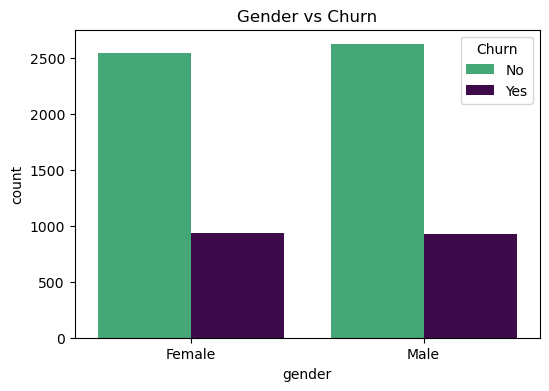

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(
              x='gender', 
              hue='Churn', 
              data=df, 
              palette=['#35B779', '#440154']
             )
plt.title("Gender vs Churn")
plt.show()

In [12]:
df['SeniorCitizen'].unique()

array([0, 1])

<Axes: xlabel='SeniorCitizen', ylabel='count'>

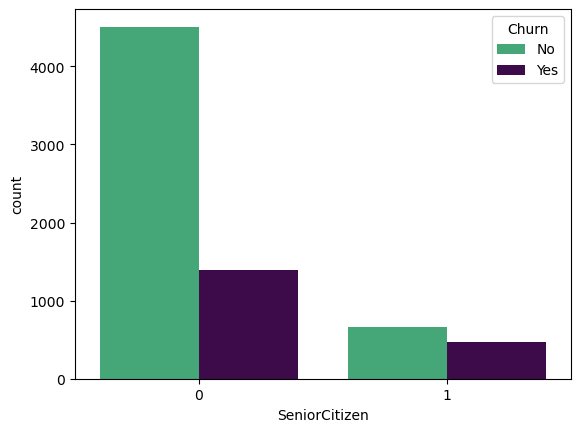

In [13]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette=['#35B779', '#440154'])


### Observation 
Senior citizens have a higher churn rate

<Axes: xlabel='Contract', ylabel='count'>

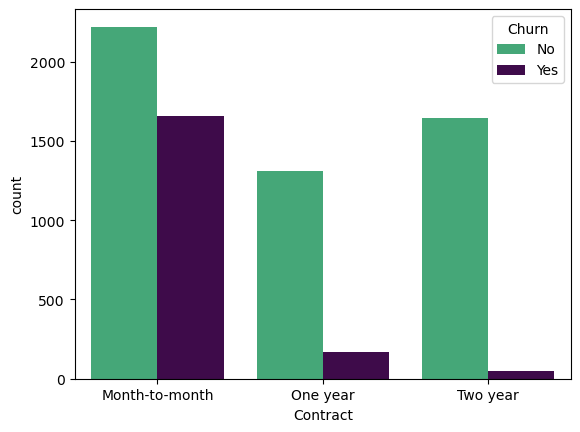

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#35B779', '#440154'])

### Observation 
Most customers who left the company's service had month-to-month contract.

<Axes: xlabel='InternetService', ylabel='count'>

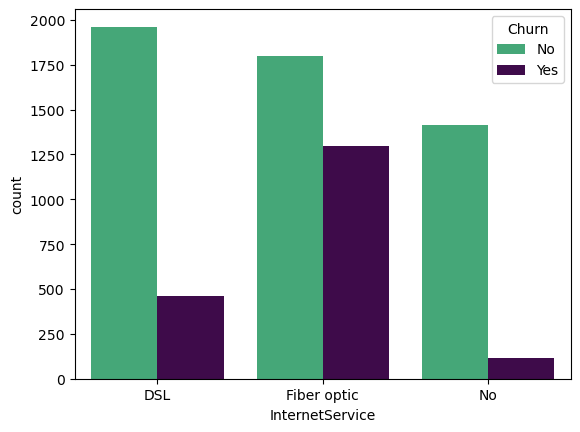

In [15]:
sns.countplot(x='InternetService', hue='Churn', data=df, palette=['#35B779', '#440154'])

### Observation
Most customer who left the company's service were using Fiber optic internet service.

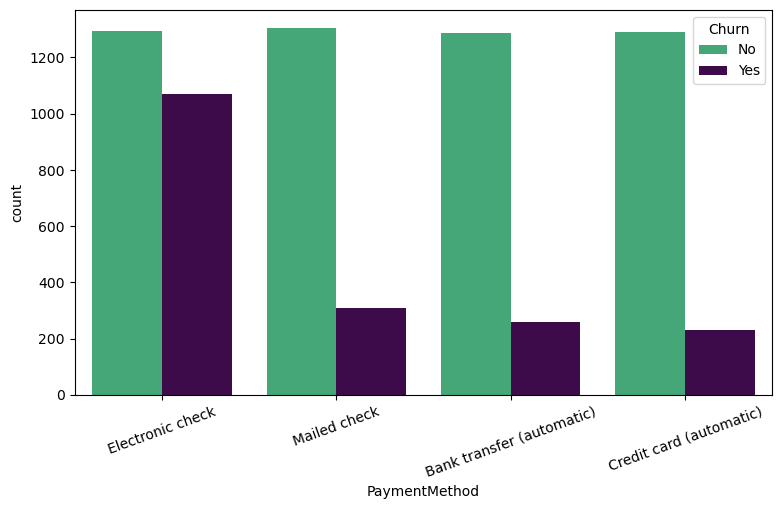

In [16]:
plt.figure(figsize=(9,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette=['#35B779', '#440154'])
plt.xticks(rotation=20)
plt.show()

### Observation
Most customer who left the company's service were using Electronic check.

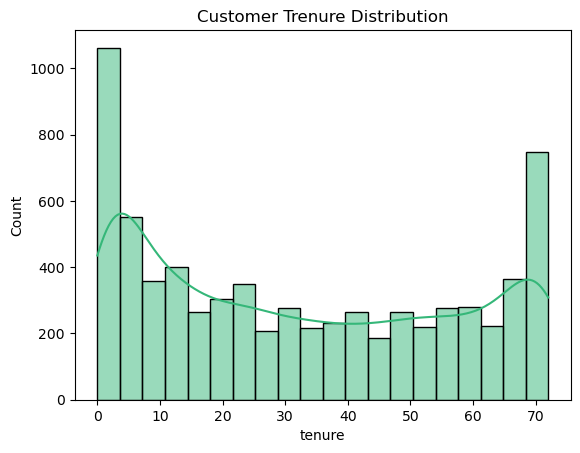

In [17]:
sns.histplot(df['tenure'], 
             bins=20, 
             kde=True, 
             color='#35B779')

plt.title('Customer Trenure Distribution')
plt.show()

### Observation
The maximum customer tenure is around 72 months, which means some customers have stayed with the company's service for up to 6 years.

<Axes: xlabel='tenure', ylabel='Count'>

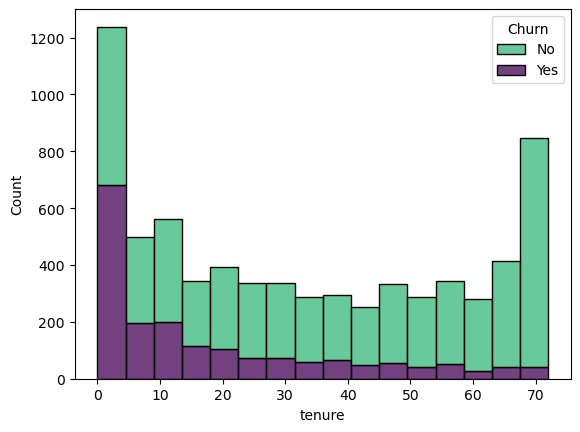

In [18]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette=['#35B779', '#440154'])

### Observation
The highest risk of churn is during the first few months of a customer's relationship. Therefore, the company should focus on improving customer experience and retention during the early months.

# Preprocessing 
Transform the categorical columns to numeric

In [19]:
df.apply(lambda x: x.unique())

customerID          [7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC...
gender                                                 [Female, Male]
SeniorCitizen                                                  [0, 1]
Partner                                                     [Yes, No]
Dependents                                                  [No, Yes]
tenure              [1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ...
PhoneService                                                [No, Yes]
MultipleLines                             [No phone service, No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                         [No, Yes, No internet service]
OnlineBackup                           [Yes, No, No internet service]
DeviceProtection                       [No, Yes, No internet service]
TechSupport                            [No, Yes, No internet service]
StreamingTV                            [No, Yes, No internet service]
StreamingMovies     

### Preprocessing

In [20]:
ordinal_encoder = OrdinalEncoder()
df[['gender', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaperlessBilling','PaymentMethod','Churn'
   ]]=ordinal_encoder.fit_transform(df[['gender', 'Partner', 'Dependents', 
                                        'PhoneService', 'MultipleLines','InternetService',
                                        'OnlineSecurity','OnlineBackup','DeviceProtection',
                                        'TechSupport','StreamingTV','StreamingMovies',
                                        'Contract','PaperlessBilling','PaymentMethod','Churn']])

In [21]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85,0.0
1,5575-GNVDE,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1889.5,0.0
2,3668-QPYBK,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,108.15,1.0
3,7795-CFOCW,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1840.75,0.0
4,9237-HQITU,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65,1.0


In [22]:
# Delete customer ID
df.drop('customerID', axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   float64
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   float64
 3   Dependents        7043 non-null   float64
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   float64
 6   MultipleLines     7043 non-null   float64
 7   InternetService   7043 non-null   float64
 8   OnlineSecurity    7043 non-null   float64
 9   OnlineBackup      7043 non-null   float64
 10  DeviceProtection  7043 non-null   float64
 11  TechSupport       7043 non-null   float64
 12  StreamingTV       7043 non-null   float64
 13  StreamingMovies   7043 non-null   float64
 14  Contract          7043 non-null   float64
 15  PaperlessBilling  7043 non-null   float64
 16  PaymentMethod     7043 non-null   float64


## Data cleaning

In [27]:
print(f"Data type before convertion: {df['TotalCharges'].dtype}")
print(f"Blank values: {(df['TotalCharges'] == ' ').sum()}")

Data type before convertion: object
Blank values: 11


The **TotalCharges** Column Contains blank values represented as spaces
They are replaced with NAN before Converting the column to numeric data type.

In [28]:
df['TotalCharges']=df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [32]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [34]:
# remove null values
df.dropna(inplace=True)

In [35]:
print(f"Data type After convertion: {df['TotalCharges'].dtype}")
print(f"Blank values: {(df['TotalCharges'] == ' ').sum()}")

Data type After convertion: float64
Blank values: 0


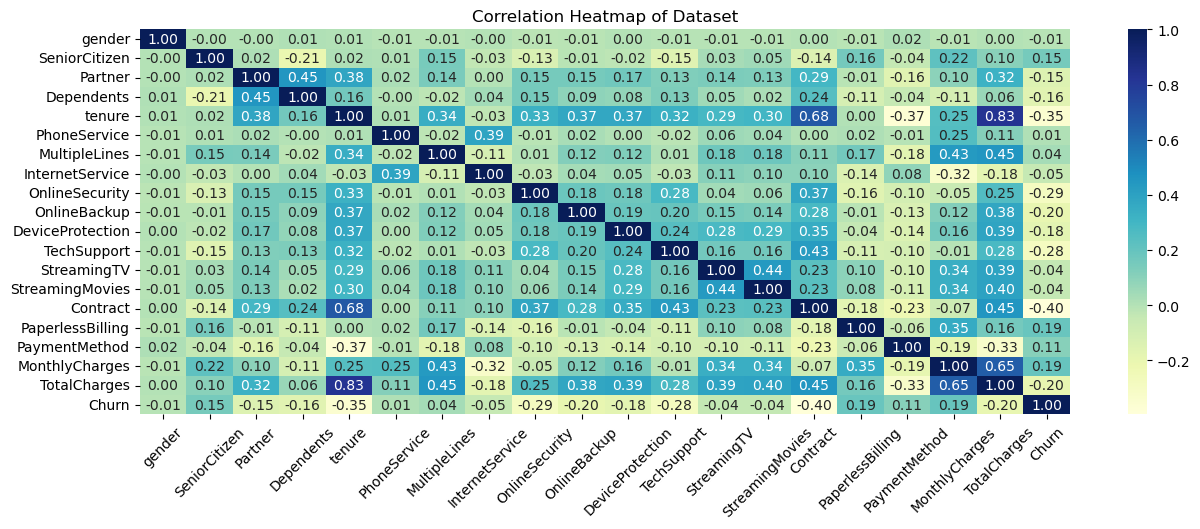

In [39]:
plt.figure(figsize=(15, 5))
sns.heatmap(df.corr(), annot=True, fmt='0.2f', cmap='YlGnBu')
plt.title('Correlation Heatmap of Dataset')
plt.xticks(rotation=45)
plt.show()

## Model Training
Several machine learning algorithms are trained and evaluated to identify the best fit model.

In [40]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=100),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVC':SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Randome Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM' : LGBMClassifier(random_state=42, verbose=-1),
    'CatBosst' : CatBoostClassifier(random_state=42, verbose=0)
}

In [41]:
y = df['Churn']
x = df.drop(['Churn'], axis=1)

In [42]:
y.head()

0    0.0
1    0.0
2    1.0
3    0.0
4    1.0
Name: Churn, dtype: float64

In [43]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,29.85
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1889.50
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,108.15
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1840.75
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,151.65


In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Model Performence Comparision

In [52]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
results = []

best_model = None
best_model_name = ""
best_f1 = 0

for name, model in models.items():

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model':name,
        'Accuracy' : accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df    

,Model,Accuracy,Precision,Recall,F1 Score
4,Randome Forest,0.792466,0.644366,0.489305,0.556231
7,CatBosst,0.786780,0.622517,0.502674,0.556213
0,Logistic Regression,0.782516,0.610390,0.502674,0.551320
6,LightGBM,0.777541,0.602007,0.481283,0.534918
1,KNN,0.772566,0.597122,0.443850,0.509202
5,XGBoost,0.769723,0.581699,0.475936,0.523529
2,SVC,0.734186,0.000000,0.000000,0.000000
3,Decision Tree,0.724947,0.483791,0.518717,0.500645


In [53]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Features':x_train.columns,
    'Importance':importances
}).sort_values('Importance', ascending=False)


Text(0.5, 1.0, 'Top 10 Important Features')

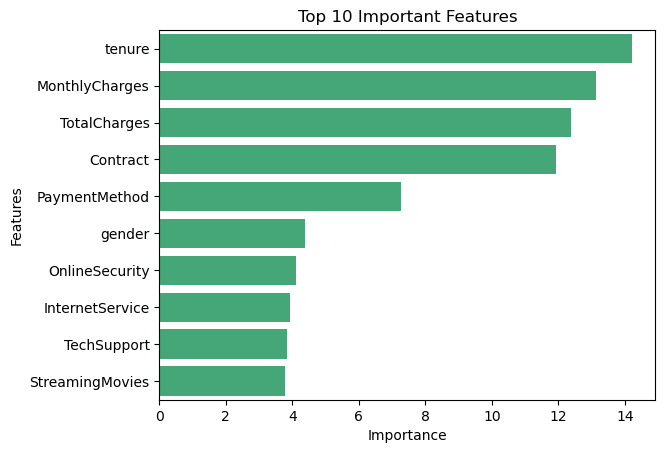

In [54]:
sns.barplot(data=importance_df.head(10), color='#35B779',
           x = 'Importance',
           y = 'Features')
plt.title("Top 10 Important Features")

## Confusion Matrix
The confusion matrix provides a detailed view of correct and incorrect prediction made by the model

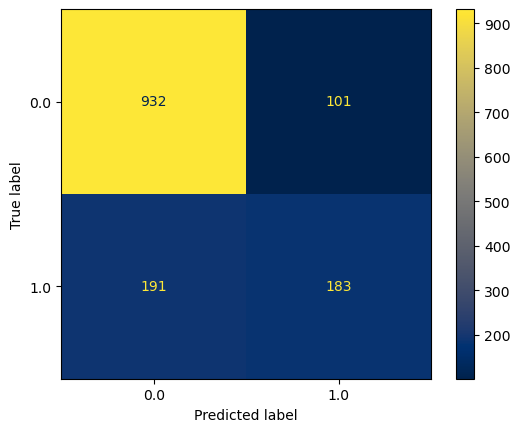

In [60]:
ConfusionMatrixDisplay.from_estimator(best_model, 
                                      x_test, 
                                      y_test, 
                                      cmap='cividis')
plt.show()

## Predict Customer Churn
Use the trained model to predict whether a new customer is likely to stay or leave the company

In [61]:
def predict_customer(model, customer_data):
    prediction = model.predict(customer_data)[0]

    return "stay" if prediction == 0 else "Chuen"

In [62]:
new_customer = pd.DataFrame([[
    0,      # gender
    0,      # SeniorCitizen
    1,      # Partner
    2,      # Dependents
    34,     # tenure
    1,      # PhoneService
    0,      # MultipleLines
    1,      # InternetService
    0,      # OnlineSecurity
    1,      # OnlineBackup
    0,      # DeviceProtection
    0,      # TechSupport
    1,      # StreamingTV
    1,      # StreamingMovies
    1,      # Contract
    1,      # PaperlessBilling
    2,      # PaymentMethod
    79.50,  # MonthlyCharges
    1239.00, # TotalCharges
    # 0,       # partner
]], columns=x_train.columns)


print("Customer will:", predict_customer(best_model, new_customer))

Customer will: stay


## Action:
I explored and prepared the data, encoded categorical features, split the dataset into training and testing sets, trained multiple machine learning models, compared their performance using Accuracy, Precision, Recall, and F1 Score, and selected the best-performing model.

## Result:

Random Forest achieved the best accuracy of about 79.2%. I also used a Confusion Matrix to evaluate the model and gained practical experience in building and evaluating machine learning models.